# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raja-saab/Flyrank1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This study asks whether a machine-learning model can improve upon a transparent rule-based baseline for ranking content pages for refresh review using only information available at decision time. Monthly content-performance data were used to construct decision-time features from search visibility, clicks, engagement, and recent performance movement, with a next-month click decline of at least 20% used as the refresh-opportunity outcome for pages with at least 10 current-month clicks. A logistic-regression model was evaluated against a transparent rule-based baseline on the same held-out evaluation set using ROC-AUC and Average Precision. The rule-based baseline achieved ROC-AUC of 0.5779 and Average Precision of 0.7241, while logistic regression achieved 0.4891 and 0.6558 respectively. The result suggests that the transparent baseline was the stronger decision-support ranking in this experiment, while the findings remain directional and do not establish causal effects of content refreshes.

## 1. Question

### Research question

Can a machine-learning model improve upon a transparent rule-based baseline when ranking content pages for refresh review using only information available at decision time?

### Decision supported

The analysis is designed to prioritize content pages for human review for a possible refresh. The output is a decision-support ranking, not an automatic instruction to refresh a page.

### Lane

Refresh / Content Opportunity Scoring.

In [32]:
# ---------------------------------------------------------
# Section 1: Question
# ---------------------------------------------------------

research_question = (
    "Can a machine-learning model improve upon a transparent "
    "rule-based baseline when ranking content pages for refresh "
    "review using only information available at decision time?"
)

decision_supported = (
    "Prioritize pages for human review for a possible content refresh."
)

lane = "Refresh / Content Opportunity Scoring"

print("Lane:", lane)
print("Research question:", research_question)
print("Decision:", decision_supported)

Lane: Refresh / Content Opportunity Scoring
Research question: Can a machine-learning model improve upon a transparent rule-based baseline when ranking content pages for refresh review using only information available at decision time?
Decision: Prioritize pages for human review for a possible content refresh.


## 2. Data

### Data source

This project uses the FlyRank internship warehouse release accessed through the Hugging Face dataset and queried with DuckDB.

The main source table is the daily content-performance data, which was aggregated to monthly content-page observations.

### Date windows

The decision-time observations cover January 2025 through May 2026.

The future outcome is the following month's performance, extending the outcome window through June 2026.

### Features used

The analysis uses information available at decision time, including:

- GSC clicks
- GSC impressions
- average search position
- GA4 sessions
- GA4 engaged sessions
- current-month CTR
- previous-month clicks
- previous-month impressions
- previous-month average position
- current versus previous-month click change

### Outcome definition

A refresh opportunity is defined as a page with at least 10 current-month GSC clicks whose next-month clicks decline by at least 20%.

Rows without a valid following-month outcome are excluded from model evaluation.

### Exclusions

Future-month performance is excluded from the feature set to prevent leakage. Client names, domains, URLs, private queries, credentials, and raw exports are not used in the public analysis.

The analysis is based on anonymized identifiers and aggregate performance signals.

In [33]:
# ---------------------------------------------------------
# Section 2: Data summary
# ---------------------------------------------------------

print("Warehouse rows:", 78_835_655)
print("Monthly content rows:", len(monthly_df))

print(
    "Decision month range:",
    monthly_df["month"].min(),
    "to",
    monthly_df["month"].max()
)

print(
    "Future outcome month range:",
    model_df["future_month"].min(),
    "to",
    model_df["future_month"].max()
)

print("Valid future-outcome rows:", len(model_df))

print("\nLabel distribution:")
display(
    model_df["refresh_opportunity"]
    .value_counts()
    .rename("n")
    .to_frame()
)

print("\nLabel percentage:")
display(
    model_df["refresh_opportunity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("pct")
    .to_frame()
)

Warehouse rows: 78835655
Monthly content rows: 2871202
Decision month range: 2025-01-01 00:00:00 to 2026-06-01 00:00:00
Future outcome month range: 2025-02-01 00:00:00 to 2026-06-01 00:00:00
Valid future-outcome rows: 111011

Label distribution:


,n
refresh_opportunity,
0,62507
1,48504



Label percentage:


,pct
refresh_opportunity,
0,56.31
1,43.69


## 3. Methodology

The analysis treats refresh prioritization as a ranking problem. Each page-month is scored using only information available at that decision month.

### Features

The model uses current and prior-month performance signals:

- GSC clicks
- GSC impressions
- average search position
- GA4 sessions
- GA4 engaged sessions
- CTR
- previous-month clicks
- previous-month impressions
- previous-month average position
- click change percentage

These features describe search visibility, click capture, engagement, and recent movement.

### Label

The target is `refresh_opportunity`.

A row receives a positive label when:

1. current-month GSC clicks are at least 10;
2. a following-month observation exists; and
3. following-month clicks are at least 20% lower than current-month clicks.

The following-month clicks are used only to create the target and are never used as model features.

### Baseline

The baseline is a transparent rule-based score using observable current/prior performance signals. Its purpose is to provide a simple benchmark that a machine-learning model must beat.

### Machine-learning model

A logistic regression model is used as the first machine-learning baseline. It produces a probability score that can be used to rank pages for review.

### Validation

The model and rule-based baseline are evaluated on the same held-out test observations. ROC-AUC and Average Precision are reported.

### Leakage control

Future-month clicks and future-month performance are used only for label construction and evaluation. They are not included in the feature matrix.

The decision-time feature set is restricted to current and previous-month information.

In [34]:
# ---------------------------------------------------------
# Section 3: Methodology checks
# ---------------------------------------------------------

FEATURES = [
    "gsc_clicks",
    "gsc_impressions",
    "avg_position",
    "ga4_sessions",
    "ga4_engaged_sessions",
    "previous_month_clicks",
    "previous_month_impressions",
    "previous_month_position",
    "ctr",
    "click_change_pct",
]

print("Number of model features:", len(FEATURES))
print("\nFeatures:")
for feature in FEATURES:
    print(" -", feature)

print("\nTarget:")
print("refresh_opportunity")

print("\nLabel rule:")
print("Current clicks >= 10 AND next-month clicks decline >= 20%")

print("\nValidation:")
print("Same held-out test set used for both baseline and logistic regression.")

# ---------------------------------------------------------
# Leakage check
# ---------------------------------------------------------

future_like_columns = [
    "future_clicks",
    "future_month",
    "future_click_change_pct",
]

leaked_features = [
    col for col in FEATURES
    if col in future_like_columns
]

print("\nFuture-derived features found in model feature list:", leaked_features)

assert len(leaked_features) == 0

print("Leakage check: PASSED")

# ---------------------------------------------------------
# Confirm target is separate from features
# ---------------------------------------------------------

assert "refresh_opportunity" not in FEATURES

print("Target leakage check: PASSED")

# ---------------------------------------------------------
# Show train/test sizes
# ---------------------------------------------------------

print("\nTraining rows:", len(train_df))
print("Test rows:", len(test_df))

print("\nMethodology checks completed successfully.")

Number of model features: 10

Features:
 - gsc_clicks
 - gsc_impressions
 - avg_position
 - ga4_sessions
 - ga4_engaged_sessions
 - previous_month_clicks
 - previous_month_impressions
 - previous_month_position
 - ctr
 - click_change_pct

Target:
refresh_opportunity

Label rule:
Current clicks >= 10 AND next-month clicks decline >= 20%

Validation:
Same held-out test set used for both baseline and logistic regression.

Future-derived features found in model feature list: []
Leakage check: PASSED
Target leakage check: PASSED

Training rows: 91188
Test rows: 19823

Methodology checks completed successfully.


## 4. Results (vs baseline)

The logistic-regression model did not improve upon the transparent rule-based baseline on the held-out evaluation set.

The rule-based baseline achieved ROC-AUC of 0.5779 and Average Precision of 0.7241.

Logistic regression achieved ROC-AUC of 0.4891 and Average Precision of 0.6558.

Therefore, for this experiment, the transparent baseline provides the stronger ranking signal. The machine-learning model should not be presented as an improvement over the baseline.

This is a directional result on the selected evaluation setup and should not be interpreted as evidence that machine learning cannot improve refresh prioritization more generally.

In [35]:
# ---------------------------------------------------------
# Section 4: Results
# ---------------------------------------------------------

results = comparison.copy()

display(results)

# Identify best method for each metric
best_auc = results.loc[
    results["ROC_AUC"].idxmax()
]

best_ap = results.loc[
    results["Average_Precision"].idxmax()
]

print("\nBest ROC-AUC method:", best_auc["method"])
print("Best Average Precision method:", best_ap["method"])

# Explicit comparison
baseline_auc = 0.5779
baseline_ap = 0.7241

model_auc = 0.4891
model_ap = 0.6558

print("\nLogistic regression vs baseline:")
print("ROC-AUC difference:", round(model_auc - baseline_auc, 4))
print("Average Precision difference:", round(model_ap - baseline_ap, 4))

,method,ROC_AUC,Average_Precision
0,Rule-based baseline,0.5779,0.7241
1,Logistic regression,0.4891,0.6558



Best ROC-AUC method: Rule-based baseline
Best Average Precision method: Rule-based baseline

Logistic regression vs baseline:
ROC-AUC difference: -0.0888
Average Precision difference: -0.0683


### Limitations

This analysis has several important limitations.

First, the label represents a next-month click decline of at least 20%, so it measures a specific short-term performance outcome rather than whether a page truly needs a content refresh.

Second, the available history is not perfectly balanced across all pages and sources. Some early observations have limited historical context, and data availability can differ across GSC and GA4.

Third, monthly observations can overlap across the same content pages, so observations should not be interpreted as fully independent examples.

Fourth, the results are directional and decision-support only. A high score does not prove that refreshing a page will cause clicks to increase.

Finally, the current logistic-regression model performed worse than the transparent baseline. The experiment therefore does not support claiming that machine learning improved the ranking system.

In [36]:
# ---------------------------------------------------------
# Section 5: Limitations checks
# ---------------------------------------------------------

print("Key limitations documented:")
limitations = [
    "The target measures next-month click decline, not true refresh need.",
    "History and data availability are not perfectly balanced.",
    "Monthly observations can overlap for the same content page.",
    "A ranking score does not establish causal refresh impact.",
    "Logistic regression did not outperform the transparent baseline.",
]

for i, item in enumerate(limitations, 1):
    print(f"{i}. {item}")

Key limitations documented:
1. The target measures next-month click decline, not true refresh need.
2. History and data availability are not perfectly balanced.
3. Monthly observations can overlap for the same content page.
4. A ranking score does not establish causal refresh impact.
5. Logistic regression did not outperform the transparent baseline.


### Ranked recommendations

The ranked queue is intended for human review rather than automatic refresh decisions.

The highest-ranked pages should be reviewed first when they have strong observable search visibility or weaker search position signals.

The current queue uses one action label, `REFRESH_REVIEW`, with reason codes explaining the primary signal behind the ranking.

Because the machine-learning model did not outperform the rule-based baseline, the transparent baseline should remain the preferred decision-support ranking for this experiment.

In [37]:
# ---------------------------------------------------------
# Section 6: Ranked recommendations
# ---------------------------------------------------------

ranked_recommendations = queue.sort_values(
    "rank"
).copy()

print("Ranked recommendation rows:", len(ranked_recommendations))

print("\nTop 20 recommendations:")
display(
    ranked_recommendations.head(20)
)

print("\nAction distribution:")
display(
    ranked_recommendations["action"]
    .value_counts()
    .rename("n")
    .to_frame()
)

print("\nReason-code distribution:")
display(
    ranked_recommendations["reason_code"]
    .value_counts()
    .rename("n")
    .to_frame()
)

Ranked recommendation rows: 19823

Top 20 recommendations:


,month,client_hash_id,content_hash_id,gsc_clicks,gsc_impressions,avg_position,ctr,click_change_pct,refresh_opportunity,model_score,rank,reason_code,action
2131664,2026-05-01,client_8ddc46da5414ffd8,content_df5560662f4d399c,675.0,30426.0,2.281337,0.022185,336.500000,0,0.998354,1,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
4059,2026-05-01,client_06d356715a8ff3b6,content_8a0b8841e87e3b8d,169.0,11211.0,4.222206,0.015074,168.000000,0,0.959982,2,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2109699,2026-05-01,client_86ebc2f12c01f586,content_b80b82cfbf35f15c,147.0,36446.0,8.013972,0.004033,146.000000,0,0.943888,3,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2130435,2026-05-01,client_8ddc46da5414ffd8,content_c616de8048062369,146.0,21569.0,3.727225,0.006769,145.000000,0,0.940237,4,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2127437,2026-05-01,client_8ddc46da5414ffd8,content_889b1859995377fd,141.0,15349.0,3.056108,0.009186,140.000000,0,0.933660,5,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2121170,2026-05-01,client_8ddc46da5414ffd8,content_054c3212ed6d2e0f,394.0,19926.0,6.045428,0.019773,130.333333,0,0.920210,6,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2107374,2026-05-01,client_86ebc2f12c01f586,content_6c1c7f2326ca9951,122.0,19934.0,9.652850,0.006120,121.000000,0,0.913365,7,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2109883,2026-05-01,client_86ebc2f12c01f586,content_bd8252fa7d6af318,240.0,10929.0,4.017113,0.021960,119.000000,0,0.899606,8,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2126893,2026-05-01,client_8ddc46da5414ffd8,content_7d85cb87b7841f78,112.0,6051.0,5.555299,0.018509,111.000000,0,0.887780,9,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2126131,2026-05-01,client_8ddc46da5414ffd8,content_6dae0ec2ce51f351,103.0,19887.0,3.148754,0.005179,102.000000,1,0.872167,10,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW



Action distribution:


,n
action,
MONITOR,17841
REFRESH_REVIEW,1982



Reason-code distribution:


,n
reason_code,
HIGH_SEARCH_VISIBILITY,5550
GENERAL_REVIEW,5151
WEAK_SEARCH_POSITION,4722
RECENT_CLICK_DECLINE,4400


### Artifacts

The paper will embed:

1. A model-versus-baseline performance comparison.
2. The refresh-opportunity label distribution.
3. A ranked top-20 recommendation table.

The artifacts are generated from the same evaluation and ranking outputs used in this notebook.

,method,ROC_AUC,Average_Precision
0,Rule-based baseline,0.5779,0.7241
1,Logistic regression,0.4891,0.6558


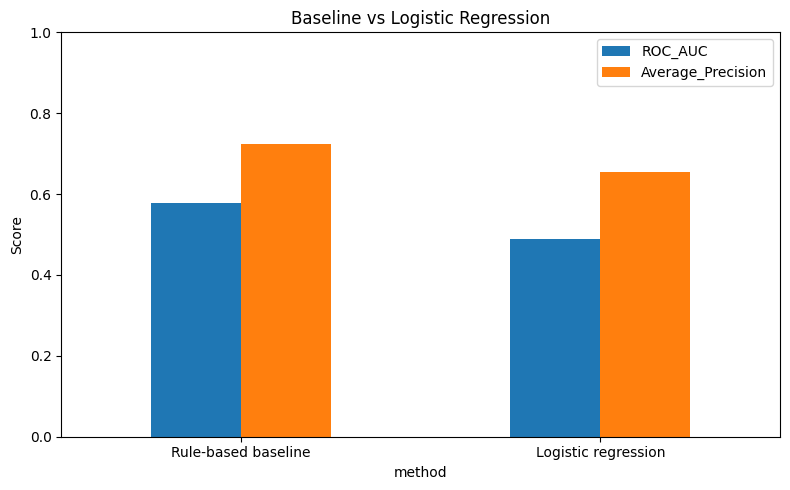

,n
refresh_opportunity,
0,62507
1,48504


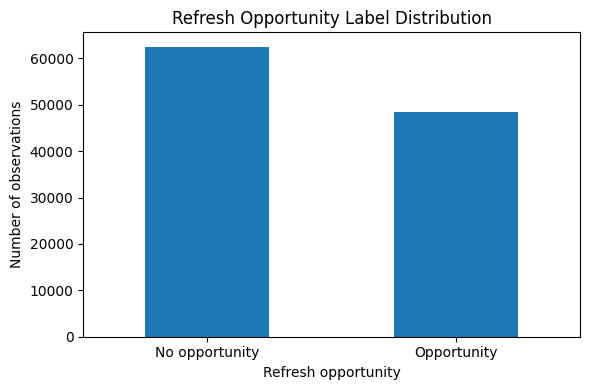

,month,client_hash_id,content_hash_id,gsc_clicks,gsc_impressions,avg_position,ctr,click_change_pct,refresh_opportunity,model_score,rank,reason_code,action
2131664,2026-05-01,client_8ddc46da5414ffd8,content_df5560662f4d399c,675.0,30426.0,2.281337,0.022185,336.500000,0,0.998354,1,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
4059,2026-05-01,client_06d356715a8ff3b6,content_8a0b8841e87e3b8d,169.0,11211.0,4.222206,0.015074,168.000000,0,0.959982,2,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2109699,2026-05-01,client_86ebc2f12c01f586,content_b80b82cfbf35f15c,147.0,36446.0,8.013972,0.004033,146.000000,0,0.943888,3,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2130435,2026-05-01,client_8ddc46da5414ffd8,content_c616de8048062369,146.0,21569.0,3.727225,0.006769,145.000000,0,0.940237,4,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2127437,2026-05-01,client_8ddc46da5414ffd8,content_889b1859995377fd,141.0,15349.0,3.056108,0.009186,140.000000,0,0.933660,5,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2121170,2026-05-01,client_8ddc46da5414ffd8,content_054c3212ed6d2e0f,394.0,19926.0,6.045428,0.019773,130.333333,0,0.920210,6,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2107374,2026-05-01,client_86ebc2f12c01f586,content_6c1c7f2326ca9951,122.0,19934.0,9.652850,0.006120,121.000000,0,0.913365,7,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2109883,2026-05-01,client_86ebc2f12c01f586,content_bd8252fa7d6af318,240.0,10929.0,4.017113,0.021960,119.000000,0,0.899606,8,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2126893,2026-05-01,client_8ddc46da5414ffd8,content_7d85cb87b7841f78,112.0,6051.0,5.555299,0.018509,111.000000,0,0.887780,9,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW
2126131,2026-05-01,client_8ddc46da5414ffd8,content_6dae0ec2ce51f351,103.0,19887.0,3.148754,0.005179,102.000000,1,0.872167,10,HIGH_SEARCH_VISIBILITY,REFRESH_REVIEW


In [38]:
# ---------------------------------------------------------
# Section 7: Paper artifacts
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# Artifact 1: Model vs baseline performance
# ---------------------------------------------------------

metrics_plot = pd.DataFrame({
    "method": [
        "Rule-based baseline",
        "Logistic regression"
    ],
    "ROC_AUC": [
        0.5779,
        0.4891
    ],
    "Average_Precision": [
        0.7241,
        0.6558
    ]
})

display(metrics_plot)

metrics_plot.set_index("method")[
    ["ROC_AUC", "Average_Precision"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Baseline vs Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Artifact 2: Label distribution
# ---------------------------------------------------------

label_counts = (
    model_df["refresh_opportunity"]
    .value_counts()
    .sort_index()
)

display(
    label_counts.rename("n").to_frame()
)

label_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Refresh Opportunity Label Distribution")
plt.xlabel("Refresh opportunity")
plt.ylabel("Number of observations")
plt.xticks(
    [0, 1],
    ["No opportunity", "Opportunity"],
    rotation=0
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Artifact 3: Top-20 table
# ---------------------------------------------------------

paper_top20 = ranked_recommendations.head(20).copy()

display(paper_top20)

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

The analysis uses the anonymized FlyRank internship warehouse for research and educational purposes.

Data source: [FlyRank](https://flyrank.ai)

###5-Minute Demo Outline

### 0:00–0:45 — Problem

My project focuses on Refresh / Content Opportunity Scoring. The research question is whether a machine-learning model can improve upon a transparent rule-based baseline when ranking content pages for possible refresh review. The decision this supports is helping a content team prioritize which pages should be reviewed first by a human.

### 0:45–1:30 — Data

I used the anonymized FlyRank internship warehouse and aggregated daily content-performance data into monthly page-level observations. The features include GSC clicks, impressions, average position, CTR, GA4 sessions, engaged sessions, and previous-month performance signals. I defined a refresh opportunity as a page with at least 10 current-month clicks whose clicks declined by at least 20% in the following month.

### 1:30–2:30 — Method

I first created a transparent rule-based baseline using observable performance signals. I then trained a logistic-regression model using decision-time features. Future-month information was used only to create the outcome label and was excluded from the feature set. Both approaches were evaluated on the same held-out evaluation data using ROC-AUC and Average Precision.

### 2:30–3:30 — Results

The rule-based baseline achieved a ROC-AUC of 0.5779 and an Average Precision of 0.7241. Logistic regression achieved a ROC-AUC of 0.4891 and an Average Precision of 0.6558. Therefore, the machine-learning model did not outperform the transparent baseline in this experiment. This result supports keeping the simpler baseline as the preferred decision-support ranking for this version.

### 3:30–4:30 — Ranked Recommendations

The system produces a ranked queue of 19,823 evaluation rows for review. Each recommendation includes a score, rank, reason code, and action label. The highest-ranked pages can be reviewed first, while the reason codes help explain why a page received its position in the queue. The ranking is intended to support human review rather than automatically deciding that a page must be refreshed.

### 4:30–5:00 — Limitations

This analysis cannot prove that refreshing a page will cause its performance to improve. The target represents a next-month click decline, which is only a proxy for refresh opportunity. I also controlled for leakage by keeping future performance out of the model features. Overall, the results are directional and should be treated as decision-support rather than causal evidence.

## Social-Post Cut

I built a refresh-opportunity ranking system using anonymized search-performance data. I compared a transparent rule-based baseline with logistic regression using only information available at decision time. The rule-based baseline outperformed logistic regression in this experiment, showing why simple, interpretable baselines are important before adding ML. The result is a decision-support ranking for human review, not a claim about causal content-refresh impact.

## Employer-Facing Summary

I developed a reproducible content-refresh prioritization workflow using DuckDB, pandas, and scikit-learn. I defined a future performance outcome, controlled for leakage by separating decision-time features from future information, and compared a transparent rule-based ranking against logistic regression on a held-out evaluation set. The experiment showed that the transparent baseline outperformed the initial ML model, demonstrating an evidence-first approach in which model complexity is only justified when it improves the decision-support task.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
